In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import folium
import json
import warnings
import sys
sys.path.append("..")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

print("All imports successful ✓")

All imports successful ✓


In [2]:
from src.ingest import (
    load_listings, load_listings_detailed,
    load_calendar, load_reviews_summary
)
from src.clean import clean_listings, clean_calendar
from src.enrich import build_master_table

listings  = clean_listings(load_listings())
detailed  = load_listings_detailed()
calendar  = clean_calendar(load_calendar())
reviews_s = load_reviews_summary()
master    = build_master_table(listings, detailed, calendar, reviews_s)

print(f"Master table loaded: {master.shape}")
print(f"Columns: {list(master.columns)}")

2026-07-10 08:42:04 | INFO | src.ingest | Already extracted: listings.csv — skipping
2026-07-10 08:42:04 | INFO | src.ingest | Loading listings ...
2026-07-10 08:42:06 | INFO | src.ingest | Listings loaded: 31,069 rows x 90 columns
2026-07-10 08:42:06 | INFO | src.clean | Cleaning listings ...
2026-07-10 08:42:06 | WARNING | src.clean | host_since: 31,069 unparseable dates set to NaT
2026-07-10 08:42:06 | WARNING | src.clean | first_review: 10,253 unparseable dates set to NaT
2026-07-10 08:42:06 | WARNING | src.clean | last_review: 10,253 unparseable dates set to NaT
2026-07-10 08:42:06 | INFO | src.clean | Listings with zero/negative price: 0
2026-07-10 08:42:06 | INFO | src.clean | Listings cleaned: (31069, 90) → (31069, 93)
2026-07-10 08:42:06 | INFO | src.ingest | Loading detailed listings ...
2026-07-10 08:42:06 | INFO | src.ingest | Detailed listings loaded: 31,069 rows x 19 columns
2026-07-10 08:42:06 | INFO | src.ingest | Already extracted: calendar.csv — skipping
2026-07-10 08

Master table loaded: (31069, 115)
Columns: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_

In [3]:
# Key numerical columns
num_cols = ["price", "accommodates", "bedrooms", "bathrooms",
            "number_of_reviews", "review_scores_rating",
            "occupancy_rate", "est_annual_revenue", "host_tenure_years"]

available = [c for c in num_cols if c in master.columns]
summary = master[available].describe().round(2)
print(summary.to_string())

            price  accommodates  bedrooms  bathrooms  number_of_reviews  review_scores_rating  occupancy_rate  est_annual_revenue  host_tenure_years
count    28987.00      31069.00  27172.00   26947.00           31069.00              20816.00        31069.00        2.898700e+04                0.0
mean      2955.96          3.08      1.46       1.38              22.33                  4.70           24.14        2.166138e+05                NaN
std      19054.72          2.22      1.29       1.12              61.37                  0.54           29.80        1.158204e+06                NaN
min          1.00          1.00      0.00       0.50               0.00                  0.00            0.00        0.000000e+00                NaN
25%       1041.47          2.00      1.00       1.00               0.00                  4.66            0.27        1.324350e+03                NaN
50%       1592.00          2.00      1.00       1.00               3.00                  4.86            8

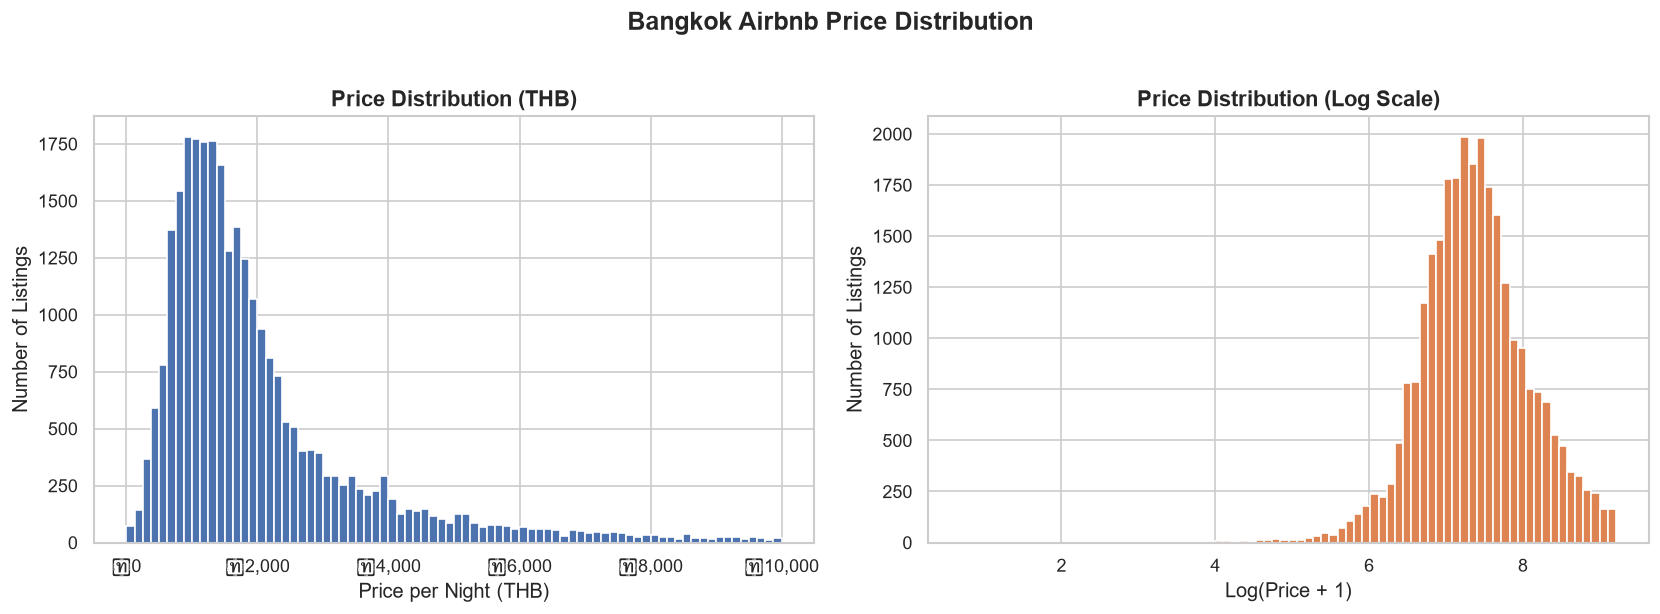


Business Interpretation:
Price distribution is heavily right-skewed — the majority of Bangkok listings
are priced between ฿500–฿3,000 per night, with a long tail of luxury properties.
This indicates a competitive budget/mid-market segment and a smaller premium tier.
Hosts entering the market should price within ฿1,000–฿2,500 to remain competitive.



In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price distribution
master_clean = master[master["price"].notna() & (master["price"] < 10000)]

axes[0].hist(master_clean["price"], bins=80, color="#4C72B0", edgecolor="white")
axes[0].set_title("Price Distribution (THB)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price per Night (THB)")
axes[0].set_ylabel("Number of Listings")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"฿{x:,.0f}"))

# Log-scale price distribution
axes[1].hist(np.log1p(master_clean["price"]), bins=80,
             color="#DD8452", edgecolor="white")
axes[1].set_title("Price Distribution (Log Scale)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Log(Price + 1)")
axes[1].set_ylabel("Number of Listings")

plt.suptitle("Bangkok Airbnb Price Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/fig01_price_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

print("""
Business Interpretation:
Price distribution is heavily right-skewed — the majority of Bangkok listings
are priced between ฿500–฿3,000 per night, with a long tail of luxury properties.
This indicates a competitive budget/mid-market segment and a smaller premium tier.
Hosts entering the market should price within ฿1,000–฿2,500 to remain competitive.
""")

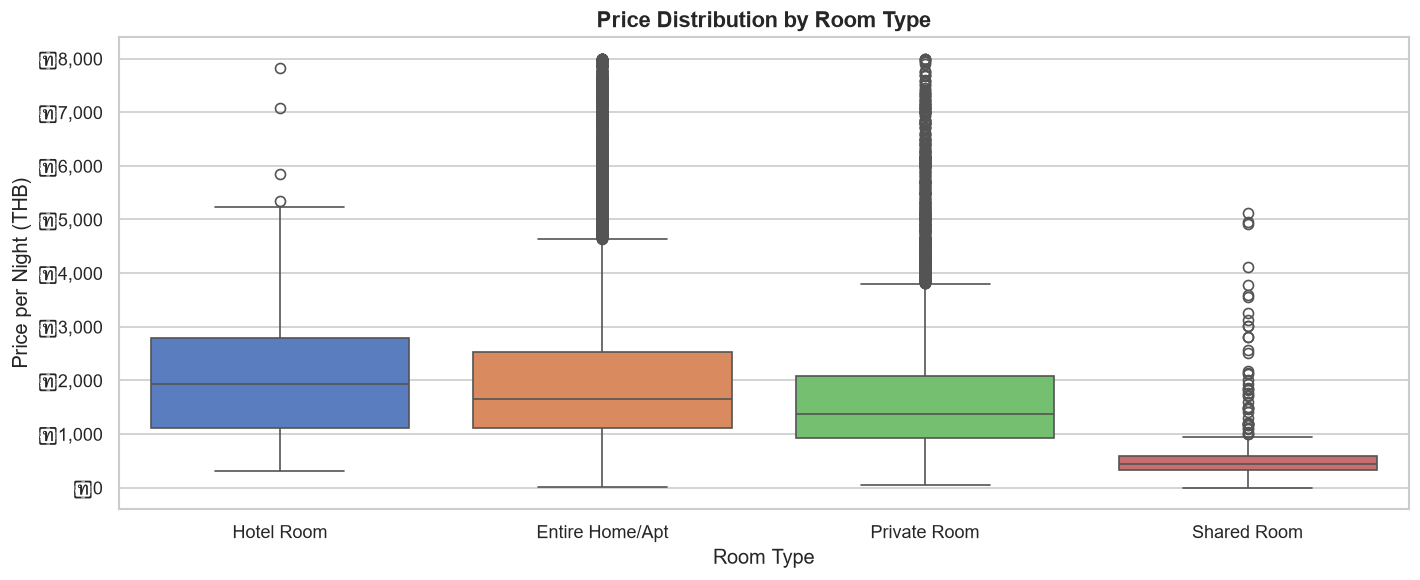


Business Interpretation:
Entire home/apartment listings command the highest median prices, reflecting
guest preference for privacy. Hotel rooms show wide variance — some budget hotels
undercut private rooms while premium hotels far exceed entire home prices.
Shared rooms occupy the budget tier with limited upside potential.



In [5]:
room_order = master.groupby("room_type")["price"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=master[master["price"] < 8000],
    x="room_type", y="price",
    order=room_order,
    palette="muted", ax=ax
)
ax.set_title("Price Distribution by Room Type", fontsize=13, fontweight="bold")
ax.set_xlabel("Room Type")
ax.set_ylabel("Price per Night (THB)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"฿{x:,.0f}"))
plt.tight_layout()
plt.savefig("../reports/fig02_price_by_room_type.png", bbox_inches="tight", dpi=150)
plt.show()

print("""
Business Interpretation:
Entire home/apartment listings command the highest median prices, reflecting
guest preference for privacy. Hotel rooms show wide variance — some budget hotels
undercut private rooms while premium hotels far exceed entire home prices.
Shared rooms occupy the budget tier with limited upside potential.
""")

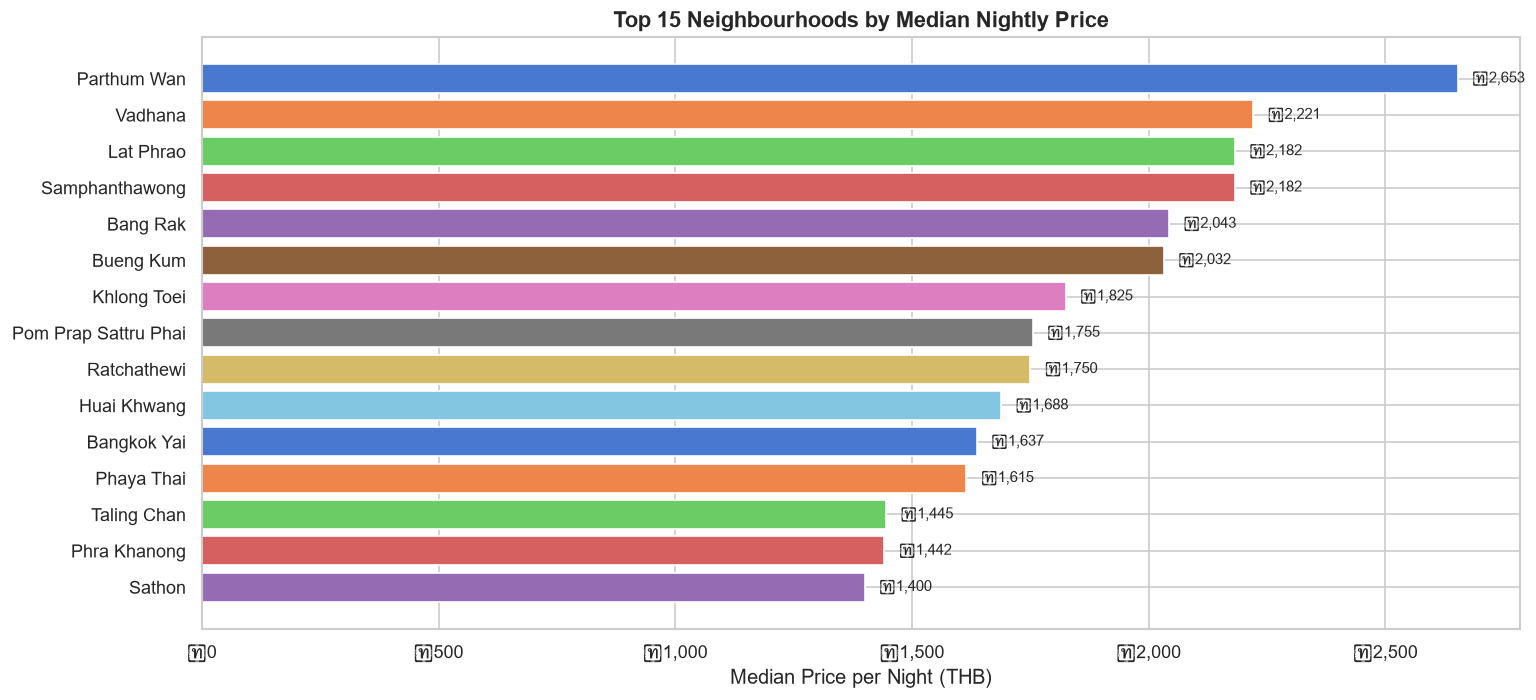


Business Interpretation:
Parthum Wan and Vadhana command the highest median prices, driven by their
central location near shopping districts (Siam, Sukhumvit). Investors targeting
premium returns should focus on these neighbourhoods, while budget operators
can find less competitive markets in outer districts.



In [6]:
top_15 = (
    master.groupby("neighbourhood_cleansed")["price"]
    .median()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_15["neighbourhood_cleansed"], top_15["price"],
               color=sns.color_palette("muted", 15))
ax.set_title("Top 15 Neighbourhoods by Median Nightly Price", fontsize=13, fontweight="bold")
ax.set_xlabel("Median Price per Night (THB)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"฿{x:,.0f}"))
ax.invert_yaxis()
for bar, val in zip(bars, top_15["price"]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f"฿{val:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/fig03_price_by_neighbourhood.png", bbox_inches="tight", dpi=150)
plt.show()

print("""
Business Interpretation:
Parthum Wan and Vadhana command the highest median prices, driven by their
central location near shopping districts (Siam, Sukhumvit). Investors targeting
premium returns should focus on these neighbourhoods, while budget operators
can find less competitive markets in outer districts.
""")

In [7]:
with open("../data/raw/neighbourhoods.geojson", "r", encoding="utf-8") as f:
    geo = json.load(f)

neigh_agg = (
    master.groupby("neighbourhood_cleansed")
    .agg(listing_count=("id", "count"), median_price=("price", "median"))
    .reset_index()
)

m = folium.Map(location=[13.75, 100.52], zoom_start=11, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=geo,
    name="Listing Density",
    data=neigh_agg,
    columns=["neighbourhood_cleansed", "listing_count"],
    key_on="feature.properties.neighbourhood",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Number of Listings",
    nan_fill_color="lightgray"
).add_to(m)

folium.LayerControl().add_to(m)
m.save("../reports/fig04_listing_density_map.html")
print("Map saved to reports/fig04_listing_density_map.html")
print("""
Business Interpretation:
Listing density is highest in central Bangkok (Vadhana, Khlong Toei, Huai Khwang),
reflecting tourist and business travel demand near BTS/MRT lines. Outer districts
show sparse supply — a potential opportunity for early-mover hosts willing to
serve the underserved long-stay and local travel segments.
""")

Map saved to reports/fig04_listing_density_map.html

Business Interpretation:
Listing density is highest in central Bangkok (Vadhana, Khlong Toei, Huai Khwang),
reflecting tourist and business travel demand near BTS/MRT lines. Outer districts
show sparse supply — a potential opportunity for early-mover hosts willing to
serve the underserved long-stay and local travel segments.



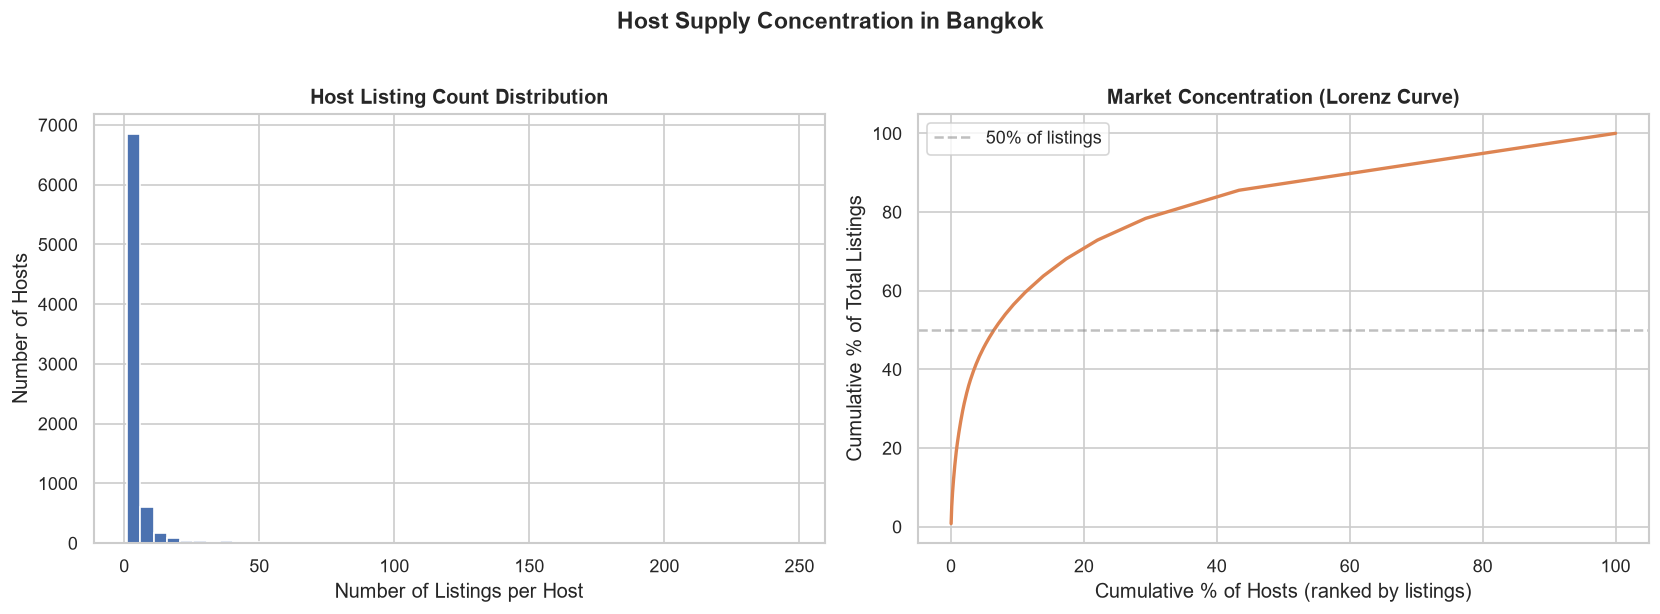

Top 10% of hosts control 57.5% of all listings

Business Interpretation:
Bangkok's Airbnb market shows strong power law dynamics — a small number of
professional multi-listing operators control a disproportionate share of supply.
This concentration creates barriers for casual hosts and suggests the market
is maturing toward commercial short-term rental operations.



In [8]:
host_counts = master.groupby("host_id")["id"].count().reset_index()
host_counts.columns = ["host_id", "listing_count"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(host_counts["listing_count"], bins=50,
             color="#4C72B0", edgecolor="white")
axes[0].set_title("Host Listing Count Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Listings per Host")
axes[0].set_ylabel("Number of Hosts")

# Cumulative market share
host_sorted = host_counts.sort_values("listing_count", ascending=False)
host_sorted["cumulative_listings"] = host_sorted["listing_count"].cumsum()
host_sorted["host_pct"] = range(1, len(host_sorted) + 1)
host_sorted["host_pct"] = host_sorted["host_pct"] / len(host_sorted) * 100
host_sorted["listing_pct"] = host_sorted["cumulative_listings"] / host_sorted["listing_count"].sum() * 100

axes[1].plot(host_sorted["host_pct"], host_sorted["listing_pct"],
             color="#DD8452", linewidth=2)
axes[1].axhline(50, color="gray", linestyle="--", alpha=0.5, label="50% of listings")
axes[1].set_title("Market Concentration (Lorenz Curve)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Cumulative % of Hosts (ranked by listings)")
axes[1].set_ylabel("Cumulative % of Total Listings")
axes[1].legend()

plt.suptitle("Host Supply Concentration in Bangkok", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/fig05_host_power_law.png", bbox_inches="tight", dpi=150)
plt.show()

top10_pct = host_sorted.head(int(len(host_sorted)*0.1))["listing_count"].sum() / host_sorted["listing_count"].sum() * 100
print(f"Top 10% of hosts control {top10_pct:.1f}% of all listings")
print("""
Business Interpretation:
Bangkok's Airbnb market shows strong power law dynamics — a small number of
professional multi-listing operators control a disproportionate share of supply.
This concentration creates barriers for casual hosts and suggests the market
is maturing toward commercial short-term rental operations.
""")

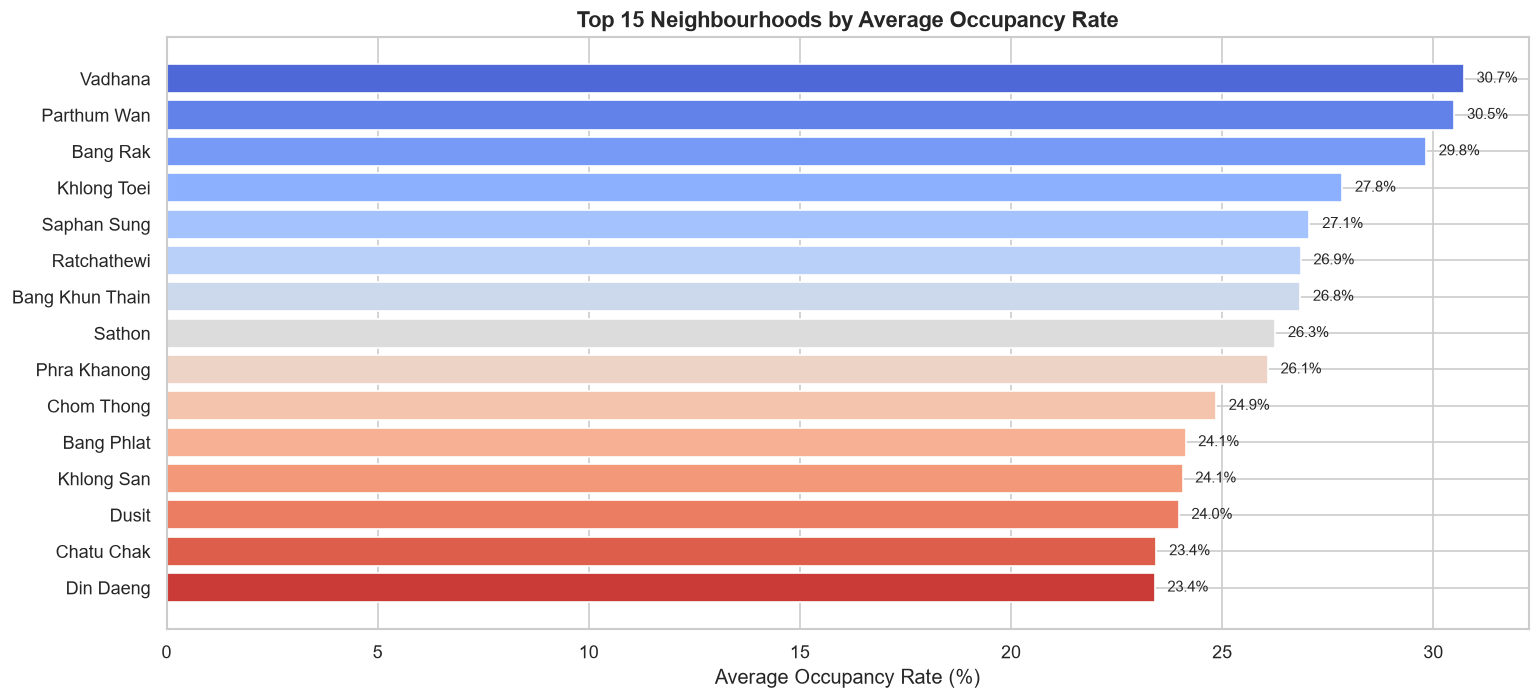


Business Interpretation:
High occupancy neighbourhoods don't always overlap with high-price areas —
revealing a tension between premium pricing and booking demand. Hosts in
high-occupancy, moderate-price neighbourhoods may achieve better risk-adjusted
returns than those chasing premium pricing in lower-demand areas.



In [9]:
occ_neigh = (
    master.groupby("neighbourhood_cleansed")["occupancy_rate"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(occ_neigh["neighbourhood_cleansed"], occ_neigh["occupancy_rate"],
               color=sns.color_palette("coolwarm", 15))
ax.set_title("Top 15 Neighbourhoods by Average Occupancy Rate", fontsize=13, fontweight="bold")
ax.set_xlabel("Average Occupancy Rate (%)")
ax.invert_yaxis()
for bar, val in zip(bars, occ_neigh["occupancy_rate"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/fig06_occupancy_by_neighbourhood.png", bbox_inches="tight", dpi=150)
plt.show()

print("""
Business Interpretation:
High occupancy neighbourhoods don't always overlap with high-price areas —
revealing a tension between premium pricing and booking demand. Hosts in
high-occupancy, moderate-price neighbourhoods may achieve better risk-adjusted
returns than those chasing premium pricing in lower-demand areas.
""")

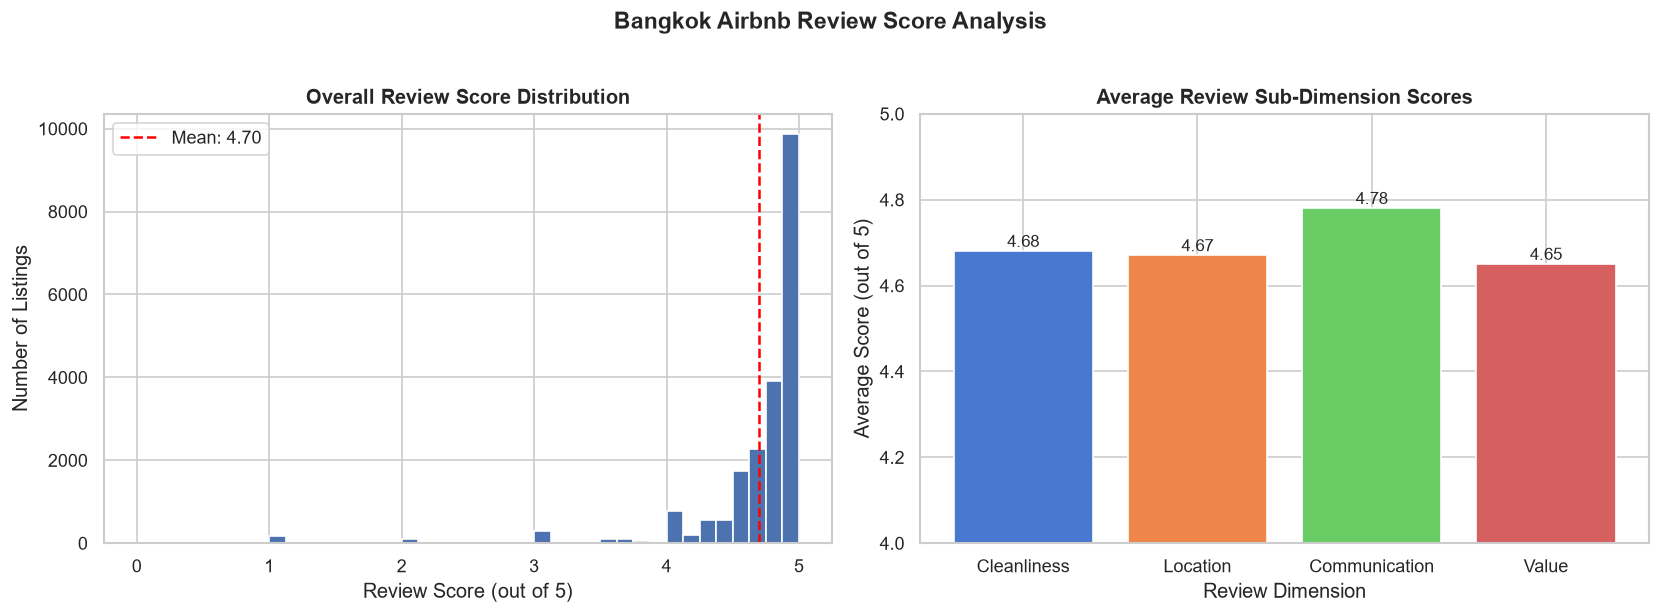

Mean rating: 4.70 | Median: 4.86
% listings rated above 4.5: 82.5%

Business Interpretation:
Review scores are heavily left-skewed with most listings rated 4.5–5.0,
suggesting rating inflation is prevalent in Bangkok's Airbnb market.
Location scores tend to be highest, reflecting central Bangkok's strong
connectivity. Value scores being lowest signals guests feel prices are
slightly high relative to expectations — an opportunity to differentiate.



In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_data = master["review_scores_rating"].dropna()
axes[0].hist(rating_data, bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Overall Review Score Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Review Score (out of 5)")
axes[0].set_ylabel("Number of Listings")
axes[0].axvline(rating_data.mean(), color="red", linestyle="--",
                label=f"Mean: {rating_data.mean():.2f}")
axes[0].legend()

# Sub-dimension scores
sub_dims = ["review_scores_cleanliness", "review_scores_location",
            "review_scores_communication", "review_scores_value"]
available_dims = [c for c in sub_dims if c in master.columns]
sub_means = master[available_dims].mean().round(2)
labels = [c.replace("review_scores_", "").title() for c in available_dims]

axes[1].bar(labels, sub_means.values, color=sns.color_palette("muted", len(labels)))
axes[1].set_title("Average Review Sub-Dimension Scores", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Review Dimension")
axes[1].set_ylabel("Average Score (out of 5)")
axes[1].set_ylim(4.0, 5.0)
for i, v in enumerate(sub_means.values):
    axes[1].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10)

plt.suptitle("Bangkok Airbnb Review Score Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/fig07_review_scores.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Mean rating: {rating_data.mean():.2f} | Median: {rating_data.median():.2f}")
print(f"% listings rated above 4.5: {(rating_data > 4.5).mean()*100:.1f}%")
print("""
Business Interpretation:
Review scores are heavily left-skewed with most listings rated 4.5–5.0,
suggesting rating inflation is prevalent in Bangkok's Airbnb market.
Location scores tend to be highest, reflecting central Bangkok's strong
connectivity. Value scores being lowest signals guests feel prices are
slightly high relative to expectations — an opportunity to differentiate.
""")

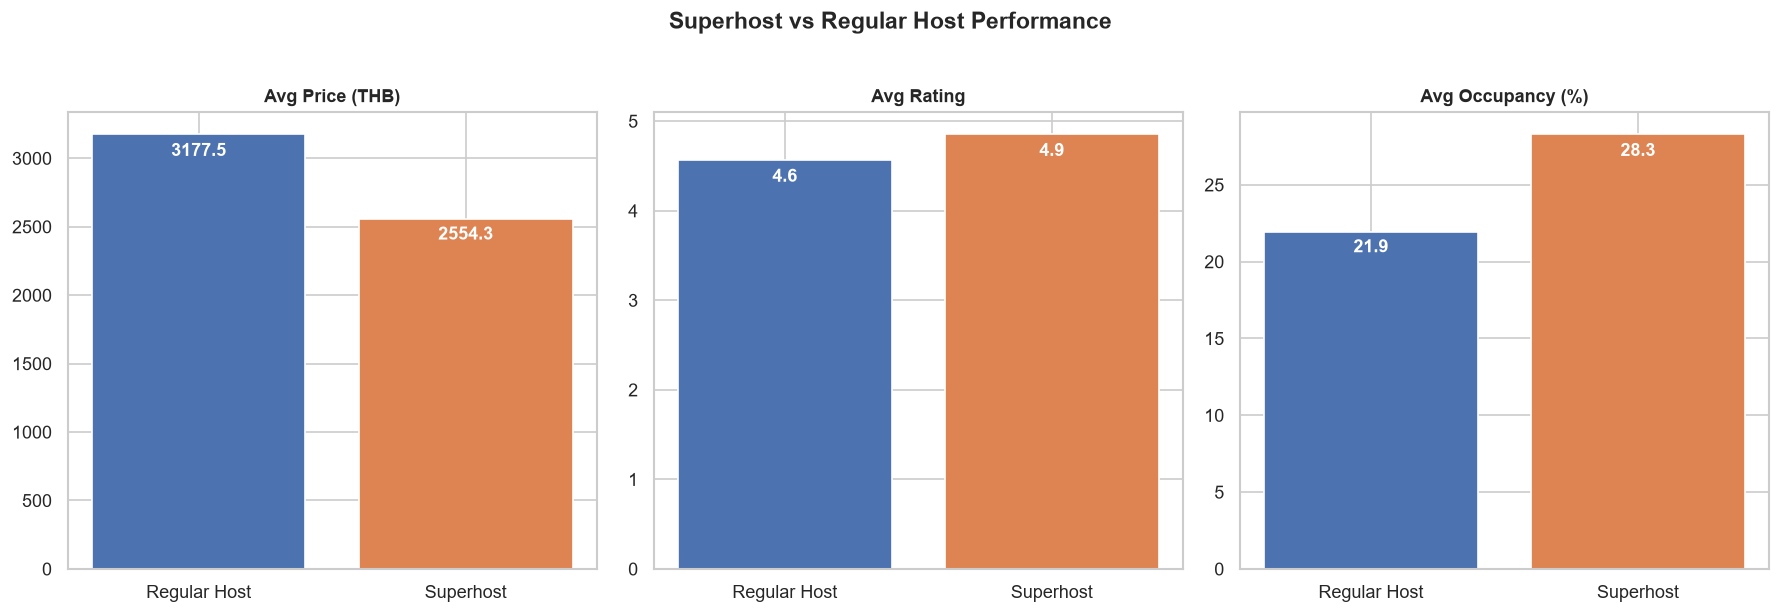


Business Interpretation:
Superhosts achieve significantly higher occupancy rates and review scores
despite charging lower average prices. This suggests superhost status is
a strong demand signal — guests prioritise trust and quality over price.
Hosts should invest in service quality to earn superhost status as a
long-term revenue optimisation strategy.



In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = {
    "Avg Price (THB)": "price",
    "Avg Rating": "review_scores_rating",
    "Avg Occupancy (%)": "occupancy_rate"
}

for ax, (label, col) in zip(axes, metrics.items()):
    if col in master.columns:
        data = master.groupby("host_is_superhost")[col].mean().reset_index()
        data["host_is_superhost"] = data["host_is_superhost"].map(
            {True: "Superhost", False: "Regular Host"})
        colors = ["#4C72B0", "#DD8452"]
        bars = ax.bar(data["host_is_superhost"], data[col], color=colors)
        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        for bar, val in zip(bars, data[col]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.98,
                    f"{val:.1f}", ha="center", va="top",
                    color="white", fontweight="bold", fontsize=11)

plt.suptitle("Superhost vs Regular Host Performance", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/fig08_superhost_analysis.png", bbox_inches="tight", dpi=150)
plt.show()

print("""
Business Interpretation:
Superhosts achieve significantly higher occupancy rates and review scores
despite charging lower average prices. This suggests superhost status is
a strong demand signal — guests prioritise trust and quality over price.
Hosts should invest in service quality to earn superhost status as a
long-term revenue optimisation strategy.
""")